[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/Quantlets/Ch_01/TSA_ch1_acf_pacf/TSA_ch1_acf_pacf.ipynb)

# TSA_ch1_acf_pacf

Sample and theoretical ACF of white noise, AR(1), MA(1) and a random walk; the sampling distribution of the sample ACF of white noise against Bartlett's N(0, 1/T) and the number of lags outside the 95% band; sample ACF and PACF of AR(1), AR(2) and MA(1); ACF of BET daily returns, absolute and squared returns.

*Time Series Analysis (TSA), Chapter 1: Stochastic processes and stationarity. Author: Daniel Traian Pele.*

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_1'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/Quantlets/Ch_01/TSA_ch1_acf_pacf


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # default size about 7 inches wide (as in MFM); a chart is shown 11-13 cm wide on a slide, so these font sizes
    # give 7-9 pt text there. Multi-panel charts should stay near 7-7.6 inches wide: at 10-11 inches the axis
    # text drops to about 5 pt on the slide.
    rc['figure.figsize'] = (7.0, 3.4)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Analysis

In [5]:
from statsmodels.tsa.stattools import acf, pacf

from statsmodels.stats.diagnostic import acorr_ljungbox

SEED = 2026

GDP_REAL = ('namq_10_gdp', 'Q.CLV10_MEUR.NSA.B1GQ.RO')

GDP_NOMINAL = ('namq_10_gdp', 'Q.CP_MEUR.NSA.B1GQ.RO')

HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')

START = '2000-01-01'

BAND_COL = st.IDAred

NAME = {'bet': 'BET', 'sp500': 'S&P 500'}

def ro_gdp(kind='real'):
    """Romanian quarterly GDP (Eurostat), million EUR, not seasonally adjusted: 'real' or 'nominal'."""
    ds, key = GDP_REAL if kind == 'real' else GDP_NOMINAL
    return read_eurostat(ds, key).rename(f'gdp_{kind}')


def ro_hicp():
    """Romanian HICP (Eurostat, monthly, 2015 = 100)."""
    return read_eurostat(*HICP).rename('hicp')


def sample_acf(x, nlags=20):
    """Sample ACF rho(1..nlags) with the divisor T (as in Brockwell and Davis)."""
    return acf(np.asarray(x, float), nlags=nlags, fft=True)[1:]


def sample_pacf(x, nlags=20):
    """Sample PACF phi_hh, h = 1..nlags (Durbin-Levinson on the sample ACF)."""
    return pacf(np.asarray(x, float), nlags=nlags, method='ywm')[1:]


def ljung_box(x, m=10):
    """Ljung-Box Q*(m) and Box-Pierce Q(m) with their chi-square(m) p-values."""
    t = acorr_ljungbox(np.asarray(x, float), lags=[m], boxpierce=True, return_df=True).iloc[0]
    return {'lb': float(t['lb_stat']), 'lb_p': float(t['lb_pvalue']), 'bp': float(t['bp_stat']), 'bp_p': float(t['bp_pvalue'])}


def acf_bars(ax, r, T, color=st.MainBlue, theory=None, label='sample ACF', band=True):
    """ACF as bars at lags 1..len(r), with the +-1.96/sqrt(T) bands and optional theoretical values."""
    lags = np.arange(1, len(r) + 1)
    ax.bar(lags, r, width=0.55, color=color, label=label)
    if theory is not None:
        ax.plot(lags, theory, 'o', ms=4, color=st.Orange, label='theoretical ACF')
    if band:
        b = 1.96 / np.sqrt(T)
        ax.axhline(b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$')
        ax.axhline(-b, color=BAND_COL, ls='--', lw=0.9, label='_nolegend_')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    ax.set_xlim(0.3, len(r) + 0.7)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))


def simulate_arma(phi=(), theta=(), n=500, sigma=1.0, burn=500, rng=None):
    """X_t = sum phi_i X_{t-i} + e_t + sum theta_j e_{t-j}, e_t i.i.d. N(0, sigma^2), after a burn-in."""
    rng = rng if rng is not None else np.random.default_rng(SEED)
    e = rng.normal(0, sigma, n + burn)
    x = np.zeros(n + burn)
    p, q = len(phi), len(theta)
    for t in range(n + burn):
        x[t] = e[t] + sum(phi[i] * x[t - 1 - i] for i in range(p) if t - 1 - i >= 0) \
            + sum(theta[j] * e[t - 1 - j] for j in range(q) if t - 1 - j >= 0)
    return x[burn:]


def theoretical_acf(phi=(), theta=(), nlags=20):
    """Theoretical ACF of an ARMA process (statsmodels ArmaProcess), lags 1..nlags."""
    from statsmodels.tsa.arima_process import ArmaProcess
    return ArmaProcess(np.r_[1, -np.asarray(phi, float)], np.r_[1, np.asarray(theta, float)]).acf(nlags + 1)[1:]


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def fig_acf_models(n=500, nlags=20, save_it=True):
    """Sample ACF (T = 500) and theoretical ACF of white noise, AR(1) (0.8), MA(1) (0.6) and a random walk."""
    rng = np.random.default_rng(SEED + 7)
    cases = [('White noise', rng.normal(size=n), np.zeros(nlags)),
             (r'AR(1), $\phi = 0.8$', simulate_arma([0.8], n=n, rng=rng), theoretical_acf([0.8], nlags=nlags)),
             (r'MA(1), $\theta = 0.6$', simulate_arma([], [0.6], n=n, rng=rng), theoretical_acf([], [0.6], nlags=nlags)),
             ('Random walk', np.cumsum(rng.normal(size=n)), None)]
    fig, ax = plt.subplots(1, 4, figsize=(10.4, 2.9), sharey=True)
    out = {}
    for i, (a, (lab, x, th)) in enumerate(zip(ax, cases)):
        r = sample_acf(x, nlags)
        acf_bars(a, r, n, theory=th)
        a.set_title(lab)
        a.set_xlabel('lag h')
        out[lab.split(',')[0].replace('$', '')] = {'r1': float(r[0]), 'r2': float(r[1]), 'r10': float(r[9])}
    ax[0].set_ylim(-0.4, 1.05)
    st.fig_legend_bottom(fig, ncol=3, y=-0.03)
    plt.tight_layout()
    save('tsa_ch1_acf_models', save_it)
    out['th_ma1'] = 0.6 / 1.36
    return out


def fig_bartlett(T=100, nsim=10000, nlags=20, save_it=True):
    """Sample ACF of Gaussian white noise: the distribution of rho_hat(1) against N(0, 1/T), and the number of
    lags (out of 20) outside +-1.96/sqrt(T) against the Binomial(20, 0.05) distribution."""
    rng = np.random.default_rng(SEED + 8)
    r1, outside = np.empty(nsim), np.empty(nsim, int)
    b = 1.96 / np.sqrt(T)
    for i in range(nsim):
        x = rng.normal(size=T)
        r = sample_acf(x, nlags)
        r1[i] = r[0]
        outside[i] = int(np.sum(np.abs(r) > b))
    fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.2))
    ax[0].hist(r1, bins=60, density=True, color=st.MainBlue, alpha=0.6, label=rf'$\hat\rho(1)$, {nsim} samples of T = {T}')
    g = np.linspace(-0.45, 0.45, 300)
    ax[0].plot(g, stats.norm.pdf(g, 0, 1 / np.sqrt(T)), color=st.Orange, lw=1.8, label='N(0, 1/T)')
    for s in (-1, 1):
        ax[0].axvline(s * b, color=BAND_COL, ls='--', lw=0.9, label=r'$\pm 1.96/\sqrt{T}$' if s == 1 else '_nolegend_')
    ax[0].set_title(r'White noise: $\hat\rho(1) \approx N(0, 1/T)$')
    k = np.arange(0, 8)
    emp = np.array([np.mean(outside == v) for v in k])
    ax[1].bar(k - 0.18, emp, width=0.36, color=st.MainBlue, label='simulated share')
    ax[1].bar(k + 0.18, stats.binom.pmf(k, nlags, 0.05), width=0.36, color=st.Orange, label='Binomial(20, 0.05)')
    ax[1].set_title('Number of lags (of 20) outside the bands')
    ax[1].set_xlabel('lags outside')
    st.fig_legend_bottom(fig, ncol=5, y=-0.01)
    plt.tight_layout()
    save('tsa_ch1_bartlett', save_it)
    return {'sd_r1': float(r1.std()), 'sd_th': 1 / np.sqrt(T), 'mean_r1': float(r1.mean()), 'mean_th': -1 / T,
            'p_none': float(np.mean(outside == 0)), 'p_none_th': 0.95 ** nlags, 'p_one_plus': float(np.mean(outside >= 1)),
            'mean_out': float(outside.mean()), 'T': T, 'band': b}


def fig_acf_pacf(n=500, nlags=20, save_it=True):
    """Sample ACF and PACF (T = 500) of AR(1) (phi = 0.7), AR(2) (0.5, 0.3) and MA(1) (theta = 0.7)."""
    rng = np.random.default_rng(SEED + 9)
    cases = [(r'AR(1), $\phi = 0.7$', [0.7], []), (r'AR(2), $\phi_1 = 0.5$, $\phi_2 = 0.3$', [0.5, 0.3], []),
             (r'MA(1), $\theta = 0.7$', [], [0.7])]
    fig, ax = plt.subplots(2, 3, figsize=(7.4, 3.4), sharey=True)
    out = {}
    for j, (lab, ph, th) in enumerate(cases):
        x = simulate_arma(ph, th, n=n, rng=rng)
        r, p = sample_acf(x, nlags), sample_pacf(x, nlags)
        acf_bars(ax[0, j], r, n, color=st.MainBlue, label='sample ACF')
        acf_bars(ax[1, j], p, n, color=st.Forest, label='sample PACF')
        ax[0, j].set_title(lab + ': ACF', fontsize=10.5)
        ax[1, j].set_title('PACF', fontsize=10.5)
        ax[1, j].set_xlabel('lag h')
        key = ['ar1', 'ar2', 'ma1'][j]
        out[key] = {'r1': float(r[0]), 'r2': float(r[1]), 'p1': float(p[0]), 'p2': float(p[1]), 'p3': float(p[2])}
    ax[0, 0].set_ylim(-0.45, 1.0)
    st.fig_legend_bottom(fig, ncol=3, y=-0.01)
    plt.tight_layout()
    save('tsa_ch1_acf_pacf', save_it)
    out['ar2_rho1'] = 0.5 / (1 - 0.3)
    out['ar2_rho2'] = 0.5 * 0.5 / (1 - 0.3) + 0.3
    return out


def fig_returns_acf(k='bet', nlags=50, save_it=True):
    """ACF of daily log returns, absolute returns and squared returns (lags 1-50), with Ljung-Box tests."""
    r = log_returns(k, start=START)
    fig, ax = plt.subplots(1, 3, figsize=(10.4, 3.0), sharey=True)
    out = {'n': int(len(r)), 'first': r.index[0].strftime('%Y-%m-%d')}
    for i, (a, (lab, x, c)) in enumerate(zip(ax, [('$r_t$', r, st.MainBlue), (r'$|r_t|$', r.abs(), st.Forest),
                                                  ('$r_t^2$', r ** 2, st.IDAred)])):
        rr = sample_acf(x, nlags)
        acf_bars(a, rr, len(r), color=c, label='_nolegend_')
        a.set_title(f'{NAME.get(k, k)}: ACF of {lab}')
        a.set_xlabel('lag h')
        out[['r', 'abs', 'sq'][i]] = {'r1': float(rr[0]), 'r5': float(rr[4]), 'r50': float(rr[-1]),
                                      'lb10': ljung_box(x, 10)}
    ax[0].set_ylim(-0.1, 0.45)
    st.fig_legend_bottom(fig, ncol=1, y=-0.03)
    plt.tight_layout()
    save(f'tsa_ch1_{k}_acf', save_it)
    out['band'] = 1.96 / np.sqrt(len(r))
    return out

## Run

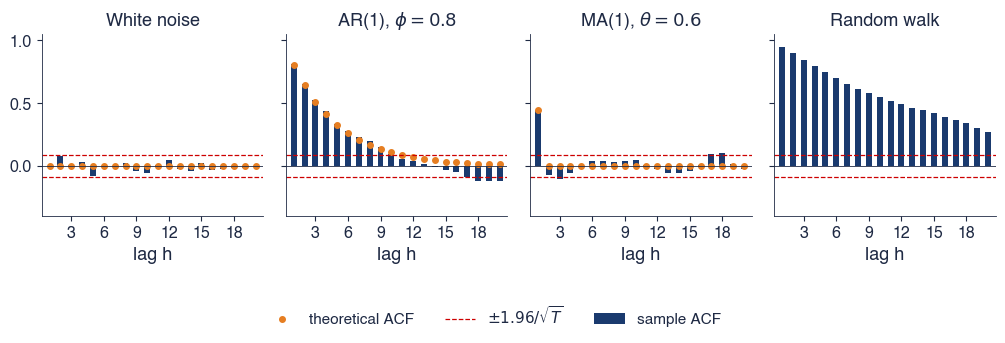

{'White noise': {'r1': 0.0028472980897001326, 'r2': 0.07927849260237989, 'r10': -0.056350274184624904}, 'AR(1)': {'r1': 0.8068751862017283, 'r2': 0.6539820662265169, 'r10': 0.09436676489272772}, 'MA(1)': {'r1': 0.4432759217900799, 'r2': -0.06874084159373518, 'r10': 0.04641329596411309}, 'Random walk': {'r1': 0.949056658679341, 'r2': 0.8970892669240196, 'r10': 0.5463336825356364}, 'th_ma1': 0.4411764705882352}


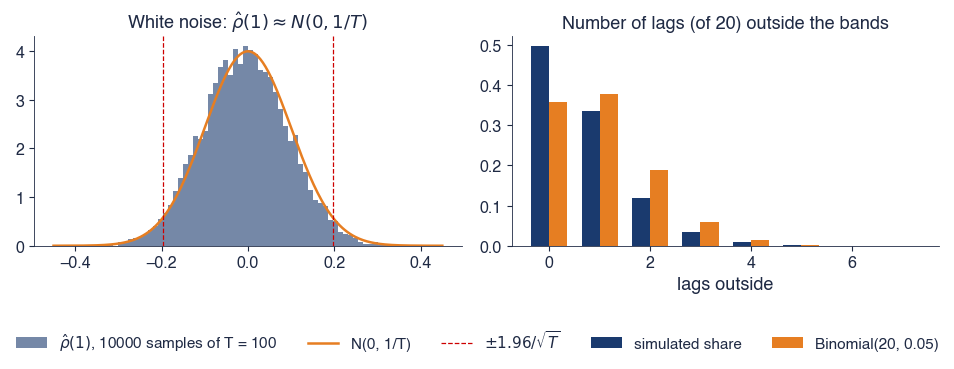

{'sd_r1': 0.09810577916108763, 'sd_th': np.float64(0.1), 'mean_r1': -0.008009803100618008, 'mean_th': -0.01, 'p_none': 0.497, 'p_none_th': 0.3584859224085419, 'p_one_plus': 0.503, 'mean_out': 0.7344, 'T': 100, 'band': np.float64(0.196)}


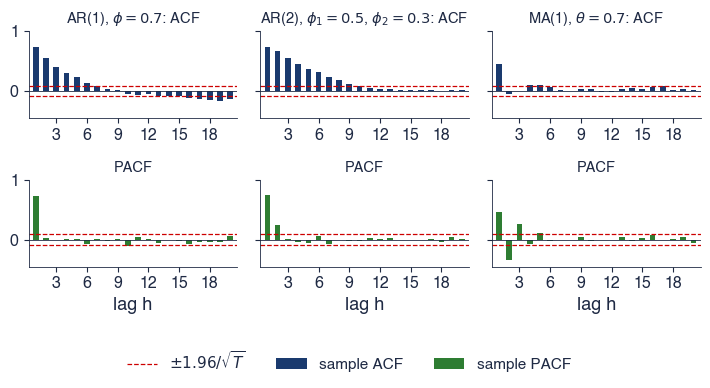

{'ar1': {'r1': 0.7307230837761999, 'r2': 0.5462642968364291, 'p1': 0.7307230837761999, 'p2': 0.026409690114077972, 'p3': -0.004529359103790036}, 'ar2': {'r1': 0.7416400187443188, 'r2': 0.6599222686409137, 'p1': 0.7416400187443192, 'p2': 0.2442214615772113, 'p3': 0.009072308122648491}, 'ma1': {'r1': 0.4579879504250916, 'r2': -0.059464516098094805, 'p1': 0.4579879504250916, 'p2': -0.3406750878361695, 'p3': 0.26499096579432246}, 'ar2_rho1': 0.7142857142857143, 'ar2_rho2': 0.6571428571428571}


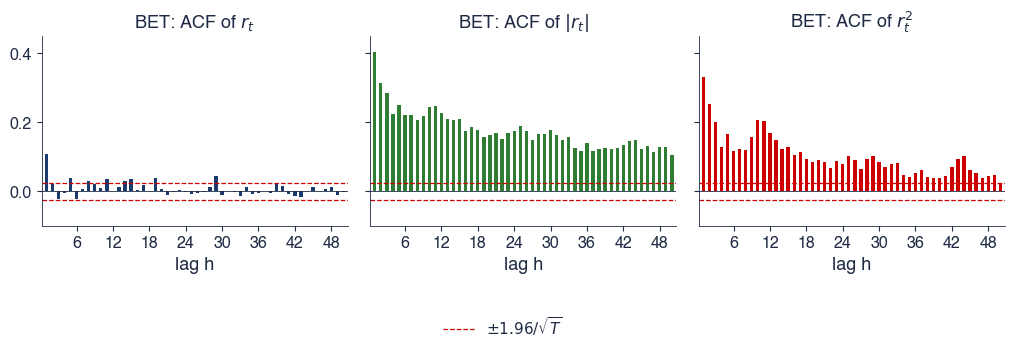

{'n': 6670, 'first': '2000-01-06', 'r': {'r1': 0.1088283261694772, 'r5': 0.03891840936470181, 'r50': -0.0009447521411234756, 'lb10': {'lb': 108.01843965612538, 'lb_p': 1.3381539580012589e-18, 'bp': 107.94946905891214, 'bp_p': 1.3816390446114093e-18}}, 'abs': {'r1': 0.40155012562184383, 'r5': 0.2501373667298849, 'r50': 0.10641890602244881, 'lb10': {'lb': 4665.0494195862275, 'lb_p': 0.0, 'bp': 4660.545130983565, 'bp_p': 0.0}}, 'sq': {'r1': 0.33043644577381215, 'r5': 0.1670668428950652, 'r50': 0.025282105061247645, 'lb10': {'lb': 2439.975217306587, 'lb_p': 0.0, 'bp': 2437.741181597664, 'bp_p': 0.0}}, 'band': np.float64(0.02399900047893674)}


In [6]:
print(fig_acf_models())
print(fig_bartlett())
print(fig_acf_pacf())
print(fig_returns_acf('bet'))

![tsa_ch1_acf_models](./tsa_ch1_acf_models.png)

Output: `tsa_ch1_acf_models.pdf`

![tsa_ch1_bartlett](./tsa_ch1_bartlett.png)

Output: `tsa_ch1_bartlett.pdf`

![tsa_ch1_acf_pacf](./tsa_ch1_acf_pacf.png)

Output: `tsa_ch1_acf_pacf.pdf`

![tsa_ch1_bet_acf](./tsa_ch1_bet_acf.png)

Output: `tsa_ch1_bet_acf.pdf`